# Effectiveness of thrombolysis in early (4hr) arrivals of mild stroke - discharge mRS 0-2: Causal Forest

## Selection criteria

* Arrival within 4 hours of known stroke onset time
* No thrombectomy
* Stroke type = infarction
* No recorded use of perfusion imaging
* Stroke severity 1-5

## Outcome of interest

* Discharge mRS 0-2.

## Key features of interest

* Onset to thrombolysis time

## Adjustment features used:

* Prior disability
* Stroke severity
* Age
* Congestive heart failure
* Hypertension
* Diabetes
* Atrial fibrillation anticoagulant
* Any atrial fibrillation diagnosis (existing or new)
* Stroke team
* Ethnicity

## Load modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import statsmodels.api as sm

from econml.dml import CausalForestDML # Causal forest with double machine learning
from lightgbm import LGBMClassifier, LGBMRegressor


# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Define mRS outcome target & time cut-off

In [2]:
MRS_TARGET = 2 # Model will set y as being less than or equal to this value

CUTOFF = 180

## Load and filter data

In [3]:
data = pd.read_csv("../../data/sam3/cleaned_data_anon_teams.csv", low_memory=False)

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 240 mins
data = data[data["onset_to_arrival_time"] < 240]

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Exlude patients who received thrombectomy
data = data[data["thrombectomy"] == 0]

# Limit to stroke severity  1 - 5 
data = data[(data["stroke_severity"] >= 1) & (data["stroke_severity"] <= 5)]

# Keep only teams with at least 10 onset_to_thrombolysis_time
team_counts = data.groupby("stroke_team")["onset_to_thrombolysis_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] <= 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

# Add mrs less than threshold
data['outcome_target'] = (data['discharge_disability'] <= MRS_TARGET).astype(int)

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")


Initial data shape: (452863, 72)
Final data shape: (58389, 73)
Number of patients with thrombolysis: 13380


Add time labels, and patient ID.

In [4]:
data.loc[data["onset_to_thrombolysis_time"] <= 180, "treatment_group"] = "<180 min"
data.loc[(data["onset_to_thrombolysis_time"] > 180) & (data["onset_to_thrombolysis_time"] <= 270), "treatment_group"] = "180-270 min"
data.loc[(data["onset_to_thrombolysis_time"] > 270) & (data["onset_to_thrombolysis_time"] <= 360), "treatment_group"] = "270-360 min"
data.loc[data["onset_to_thrombolysis_time"] == 99999, "treatment_group"] = "No thrombolysis"

# Add patient ID for honest splitting in Causal Forest

data["patient_id"] = np.arange(len(data))


## Define adjustment fields

In [5]:
# Descriptive features (not used in model building)

NON_CATEGORICAL_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
]

CATEGORICAL_FEATURES = [
    'stroke_team',
    'ethnicity',
    'treatment_group'
]

descriptive_features = list(set(NON_CATEGORICAL_FEATURES + CATEGORICAL_FEATURES))

"""
X is the set of variables you want the treatment effect to depend on. # The causal forest builds 
trees that split on X, grouping patients so that the treatment effect is roughly constant within
a leaf.

W is the set of variables you want to control for. The causal forest will adjust for these 
variables, but will not split on them.

A feature belongs in X if you think the treatment effect may vary with it, and in W if it's a
confounder you need to adjust away. Many variables are both a confounder and an effect modifier, 
so they legitimately belong in both groups.
"""


X_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
]

W_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
    'stroke_team',
]

TREATMENTS = [
    'onset_to_thrombolysis_time',
]

# Combine the X and W treatment features into a single list of features
cf_features = list(set(X_FEATURES + W_FEATURES + TREATMENTS))


## Descriptive statistics

In [6]:
# Produce descriptive stats by treatment type
descriptive_data = data[descriptive_features].copy(deep=True)
descriptive_stats = descriptive_data.groupby('treatment_group').describe()
descriptive_stats.T

treatment_group         180-270 min  270-360 min     <180 min  No thrombolysis
prior_disability count  5514.000000   476.000000  7390.000000     45009.000000
                 mean      0.567646     0.468487     0.489986         0.970939
                 std       0.966261     0.839207     0.910887         1.246288
                 min       0.000000     0.000000     0.000000         0.000000
                 25%       0.000000     0.000000     0.000000         0.000000
...                             ...          ...          ...              ...
age              min      37.500000    37.500000    37.500000        37.500000
                 25%      62.500000    62.500000    62.500000        67.500000
                 50%      72.500000    72.500000    72.500000        77.500000
                 75%      82.500000    77.500000    82.500000        82.500000
                 max      92.500000    92.500000    92.500000        92.500000

[64 rows x 4 columns]

In [7]:
ordered_arms = [
    "No thrombolysis",
    "<180 min",
    "180-270 min",
    "270-360 min"
]

# Format the descriptive stats so it shows mean ± sd and n in brackets.
# Have features as rows and treatment groups as columns.
feature_order = [
    feature
    for feature in pd.Index(descriptive_stats.columns.get_level_values(0)).unique()
    if feature != "treatment_type"
]

formatted_descriptive_stats = pd.DataFrame(index=feature_order)

for group in ordered_arms:
    if group in descriptive_stats.index:
        group_stats = descriptive_stats.loc[group]
        formatted_descriptive_stats[group] = [
            f"{group_stats[(feature, 'mean')]:.2f} ± {group_stats[(feature, 'std')]:.2f} "
            f"(n={int(group_stats[(feature, 'count')])})"
            for feature in feature_order
    ]

formatted_descriptive_stats.index.name = "feature"

# Replace _ with space in the index and column names
formatted_descriptive_stats.index = formatted_descriptive_stats.index.str.replace("_", " ")
formatted_descriptive_stats.columns = formatted_descriptive_stats.columns.str.replace("_", " ")
formatted_descriptive_stats

,No thrombolysis,<180 min,180-270 min,270-360 min
feature,,,,
prior disability,0.97 ± 1.25 (n=45009),0.49 ± 0.91 (n=7390),0.57 ± 0.97 (n=5514),0.47 ± 0.84 (n=476)
diabetes,0.23 ± 0.42 (n=45009),0.18 ± 0.38 (n=7390),0.20 ± 0.40 (n=5514),0.19 ± 0.39 (n=476)
afib anticoagulant,0.19 ± 0.39 (n=45009),0.02 ± 0.14 (n=7390),0.02 ± 0.15 (n=5514),0.03 ± 0.18 (n=476)
any afib diagnosis,0.25 ± 0.43 (n=45009),0.12 ± 0.33 (n=7390),0.12 ± 0.33 (n=5514),0.13 ± 0.33 (n=476)
stroke severity,2.66 ± 1.30 (n=45009),3.72 ± 1.17 (n=7390),3.64 ± 1.21 (n=5514),3.46 ± 1.26 (n=476)
congestive heart failure,0.06 ± 0.23 (n=45009),0.04 ± 0.18 (n=7390),0.04 ± 0.19 (n=5514),0.02 ± 0.14 (n=476)
hypertension,0.57 ± 0.50 (n=45009),0.50 ± 0.50 (n=7390),0.53 ± 0.50 (n=5514),0.51 ± 0.50 (n=476)
age,73.91 ± 13.21 (n=45009),70.45 ± 12.92 (n=7390),70.55 ± 13.27 (n=5514),69.30 ± 13.56 (n=476)


In [8]:
# Summary mean, sd, and time time to thrombolysis and thrombectomy by treatment type
summary_times = data.groupby("treatment_group")[['onset_to_thrombolysis_time']].agg(["mean", "std", "count"])
summary_times = summary_times.reindex(ordered_arms)
summary_times.round(1)

onset_to_thrombolysis_time             
                                      mean   std  count
treatment_group                                        
No thrombolysis                    99999.0   0.0  45009
<180 min                             136.7  28.8   7390
180-270 min                          221.7  25.7   5514
270-360 min                          294.0  22.2    476

## Define model

In [9]:
# ---------------------------------------------------------------------------
# Picklable LightGBM wrappers with NATIVE categorical handling.
# LightGBM (>=4.x) IGNORES `categorical_feature` on the constructor, so we
# inject it into `.fit()`. These are defined at MODULE LEVEL (not inside a
# function) so fitted EconML estimators containing them remain picklable and
# `sklearn.clone`-compatible. `cat_features` is a real constructor param, so
# get_params/set_params round-trips it (required by clone / EconML).
# ---------------------------------------------------------------------------
class CatLGBMClassifier(LGBMClassifier):
    def __init__(self, cat_features="auto", **kwargs):
        self.cat_features = cat_features
        super().__init__(**kwargs)

    def get_params(self, deep=True):
        params = super().get_params(deep=deep)
        params["cat_features"] = self.cat_features
        return params

    def fit(self, X, y, **kw):
        kw.setdefault("categorical_feature", self.cat_features)
        return super().fit(X, y, **kw)


class CatLGBMRegressor(LGBMRegressor):
    def __init__(self, cat_features="auto", **kwargs):
        self.cat_features = cat_features
        super().__init__(**kwargs)

    def get_params(self, deep=True):
        params = super().get_params(deep=deep)
        params["cat_features"] = self.cat_features
        return params

    def fit(self, X, y, **kw):
        kw.setdefault("categorical_feature", self.cat_features)
        return super().fit(X, y, **kw)

In [10]:
# EconML one-hot encodes a discrete treatment internally; the alphabetically
# first level is the baseline. We force "No thrombolysis" to sort first.
arm = data["treatment_group"].map(
    {
    "No thrombolysis": "0_No_thrombolysis",
    "<180 min": "1_<180_min",
    "180-270 min": "2_180-270_min",
    "270-360 min": "3_270-360_min"
    }
).to_numpy()

In [11]:
# ---------------------------------------------------------------------
# Categorical encoding helper for NATIVE LightGBM categorical handling
# ---------------------------------------------------------------------
def encode_categoricals_as_codes(frame, cat_cols):
    """
    Turn nominal categorical columns into NON-NEGATIVE integer codes suitable
    for LightGBM's native categorical handling (passed via `categorical_feature`
    as column indices). Unknown/missing map to a dedicated highest code rather
    than -1 (LightGBM requires non-negative category ids). Returns an (n, k)
    int array with one column per cat_col, in the given order.
    """
    codes = []
    for col in cat_cols:
        ser = frame[col].astype(str).replace({"nan": "Empty", "": "Empty"}).fillna("Empty")
        cat = ser.astype("category").cat.codes.to_numpy()   # 0..K-1, no -1 here
        codes.append(cat.astype(np.int64))
    return np.column_stack(codes) if codes else np.empty((len(frame), 0))

In [12]:
# ---------------------------------------------------------------------------
# Feature matrices
# ---------------------------------------------------------------------------
def build_matrices(data):
    """
    Returns:
      X  : heterogeneity features (pre-treatment clinical only) for CATE splits
      W  : nuisance controls (X + integer-coded categoricals) for residualising
      cat_idx : column indices in W that are categorical (for LightGBM)
      y  : binary good-outcome target
      groups : stroke_team codes for cluster-robust cross-fitting
    """
    y = (data["discharge_disability"] <= MRS_TARGET).astype(int).to_numpy()

    cat_encoded = encode_categoricals_as_codes(data, CATEGORICAL_FEATURES)

    X = data[X_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in X.columns:
            X[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    # Get the column indices of the categorical features in X
    cat_idx_x = [X.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in X.columns]

    W = data[W_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in W.columns:
            W[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    cat_idx_w = [W.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in W.columns]

    groups = data["patient_id"].to_numpy()

    return X, W, y, groups, cat_idx_x, cat_idx_w

In [13]:
X, W, y, groups, cat_idx_x, cat_idx_w = build_matrices(data)

In [14]:
def make_nuisances(discrete_treatment, cat_features_x=None, cat_features_w=None):
    """LightGBM nuisance learners with NATIVE categorical handling.
    """
    cat_idx_x = cat_features_x if cat_features_x is not None else "auto"
    cat_idx_w = cat_features_w if cat_features_w is not None else "auto"
    common = dict(
        n_estimators=400, num_leaves=31, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbosity=-1,
    )
    model_y = CatLGBMClassifier(cat_features=cat_idx_x, **common)
    if discrete_treatment:
        model_t = CatLGBMClassifier(cat_features=cat_idx_w, **common)
    else:
        model_t = CatLGBMRegressor(cat_features=cat_idx_w, **common)
        
    return model_y, model_t

In [15]:
model_y, model_t = make_nuisances(
    discrete_treatment=True,
    cat_features_x=cat_idx_x,
    cat_features_w=cat_idx_w)

In [16]:
est = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,
    discrete_outcome=True,
    n_estimators=2000,
    min_samples_leaf=25,
    max_depth=None,
    honest=True,
    cv=5,
    verbose=False,
    random_state=42,
    n_jobs=-1,
)

est.fit(y, arm, X=X, W=W, groups=groups)

In [28]:
baseline = "0_No_thrombolysis"
other_arms = ["1_<180_min", "2_180-270_min", "3_270-360_min"]

cate_results = {}

for a in other_arms:
    cate = est.effect(X.to_numpy(), T0=baseline, T1=a)
    cate_results[a] = cate
    print(f"Estimated CATE for {a}, shape: {cate.shape}")


Estimated CATE for 1_<180_min, shape: (58389, 1)
Estimated CATE for 2_180-270_min, shape: (58389, 1)
Estimated CATE for 3_270-360_min, shape: (58389, 1)


In [31]:
# Copy X to a new dataframe
cate_df = X.copy()
cate_df[f"mrs_0-{MRS_TARGET}"] = y
cate_df["treatment_group"] = data["treatment_group"]
cate_df["cate"] = 0.0  # one scalar CATE column

# Fill CATE by observed treatment arm
for a in other_arms:
    arm_label = a.split("_", 1)[1].replace("_", " ")
    mask = cate_df["treatment_group"] == arm_label
    cate_df.loc[mask, "cate"] = cate_results[a].ravel()[mask.to_numpy()]

cate_df.to_csv(f"./output/causal_forest_cate_estimates_{MRS_TARGET}.csv", index=True)

cate_df

,prior_disability,stroke_severity,age,congestive_heart_failure,hypertension,diabetes,afib_anticoagulant,any_afib_diagnosis,ethnicity,mrs_0-2,treatment_group,cate
6,2,1.0,92.5,0.0,1.0,0.0,0.0,0.0,4,1,No thrombolysis,0.0
9,3,4.0,77.5,0.0,0.0,0.0,0.0,0.0,4,0,No thrombolysis,0.0
10,1,3.0,62.5,0.0,1.0,0.0,0.0,0.0,0,1,No thrombolysis,0.0
19,0,2.0,42.5,0.0,0.0,0.0,0.0,0.0,4,1,No thrombolysis,0.0
27,3,5.0,87.5,0.0,1.0,0.0,0.0,0.0,4,0,No thrombolysis,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
452800,2,2.0,82.5,0.0,1.0,0.0,1.0,1.0,4,1,No thrombolysis,0.0
452804,0,3.0,82.5,0.0,1.0,0.0,1.0,1.0,4,1,No thrombolysis,0.0
452805,0,2.0,72.5,0.0,1.0,1.0,0.0,0.0,4,1,No thrombolysis,0.0
452810,0,3.0,67.5,0.0,0.0,0.0,0.0,0.0,3,0,No thrombolysis,0.0


In [32]:
# Calculate mean, SD, and 95% CI of CATE for each treatment arm
cate_summary = cate_df.groupby("treatment_group")["cate"].agg(["mean", "std", "count"])
cate_summary["95% CI lower"] = cate_summary["mean"] - 1.96 * cate_summary["std"] / np.sqrt(cate_summary["count"])
cate_summary["95% CI upper"] = cate_summary["mean"] + 1.96 * cate_summary["std"] / np.sqrt(cate_summary["count"])

ordered_arms = [
    "<180 min",
    "180-270 min",
    "270-360 min"
]
cate_summary = cate_summary.reindex(ordered_arms).round(4)
cate_summary

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
<180 min,0.0655,0.0638,7390,0.0641,0.0670
180-270 min,0.0376,0.0722,5514,0.0357,0.0395
270-360 min,0.0302,0.2030,476,0.0120,0.0485


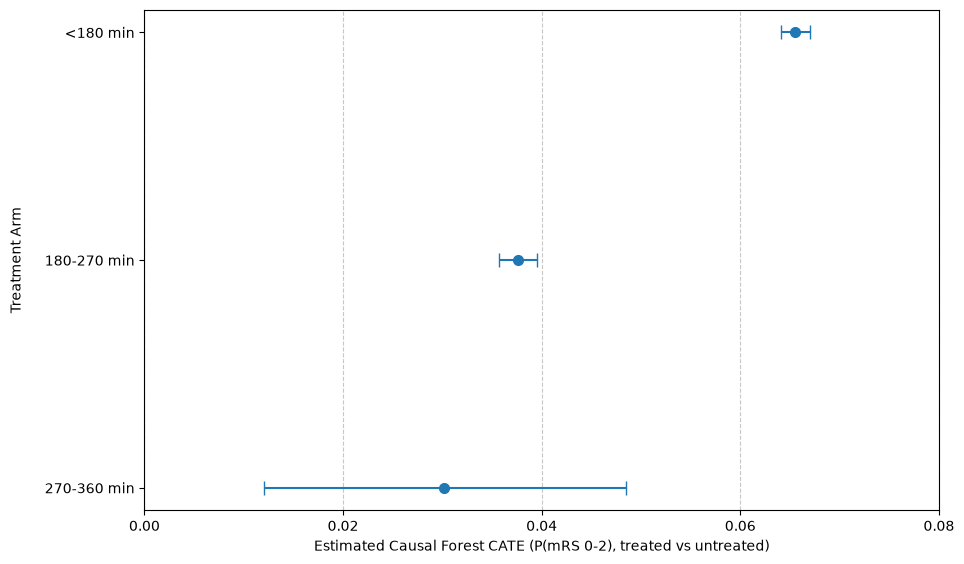

In [36]:
# Add n values to the y tick labels
n_values = cate_summary["count"].astype(int).to_dict()

fig, ax = plt.subplots(figsize=(10, 6))
# Plot the mean CATE with error bars for 95% CI
ax.errorbar(
    y=range(len(cate_summary.index) - 1, -1, -1),
    x=cate_summary["mean"],
    xerr=[
        cate_summary["mean"] - cate_summary["95% CI lower"],
        cate_summary["95% CI upper"] - cate_summary["mean"],
    ],
    fmt="o",
    markersize=7,  # increase point size
    capsize=5,
    label="Estimated CATE with 95% CI",
)
# Make x min =0
ax.set_xlim(left=0)
# x_tick at 0.02 intervals
xmin, xmax = ax.get_xlim()
ax.set_xticks(
    np.arange(
        np.floor(xmin / 0.02) * 0.02,
        np.ceil(xmax / 0.02) * 0.02 + 0.02,
        0.02
    )
)
# Add y tick labels for treatment arms
ax.set_yticks(range(len(cate_summary.index) - 1, -1, -1))
# For y tick labels replace _ with space
ax.set_yticklabels(cate_summary.index)
# Label the axes
ax.set_xlabel(f"Estimated Causal Forest CATE (P(mRS 0-{MRS_TARGET}), treated vs untreated)")
ax.set_ylabel(f"Treatment Arm", labelpad=15)
# Add grid lines
ax.grid(axis="x", linestyle="--", alpha=0.7)
# Add a horizontal line at y=0
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
plt.savefig(f"./output/causal_forest_counterfactual_cate_estimates_{MRS_TARGET}.png", dpi=300)
plt.show()